<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Pr%C3%A1cticaRegresionDatosCategoricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

# Cargar datos (sube el archivo a Colab)
df = pd.read_csv('/content/drive/MyDrive/.ipynb_checkpoints/college.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [14]:
# Carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar datos (sube el archivo a Colab)
df = pd.read_csv('/content/drive/MyDrive/.ipynb_checkpoints/college.csv')

# Seleccionar variables
df = df[['salary', 'cost', 'location']]

# Convertir location a categórica
df['location'] = df['location'].astype('category')

print("Primeras filas:")
display(df.head())

# Descripción estadística
print("\nDescripción:")
display(df[['salary', 'cost']].describe())

# Conteo por categoría
print("\nConteo por location:")
print(df['location'].value_counts())

# One-Hot Encoding (K-1)
df_dummies = pd.get_dummies(df, columns=['location'], drop_first=True)

print("\nDatos con variables dummy:")
display(df_dummies.head())


Primeras filas:


,salary,cost,location
0,119000,189300,NE
1,121000,189600,NE
2,123000,188400,NE
3,123000,188700,NE
4,110000,194200,NE



Descripción:


,salary,cost
count,85.000000,85.000000
mean,95898.823529,142434.470588
std,11937.121912,53913.064578
min,74900.000000,18260.000000
25%,87100.000000,84670.000000
50%,93200.000000,169200.000000
75%,105000.000000,188700.000000
max,123000.000000,227300.000000



Conteo por location:
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64

Datos con variables dummy:


,salary,cost,location_NE,location_S,location_W
0,119000,189300,True,False,False
1,121000,189600,True,False,False
2,123000,188400,True,False,False
3,123000,188700,True,False,False
4,110000,194200,True,False,False


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




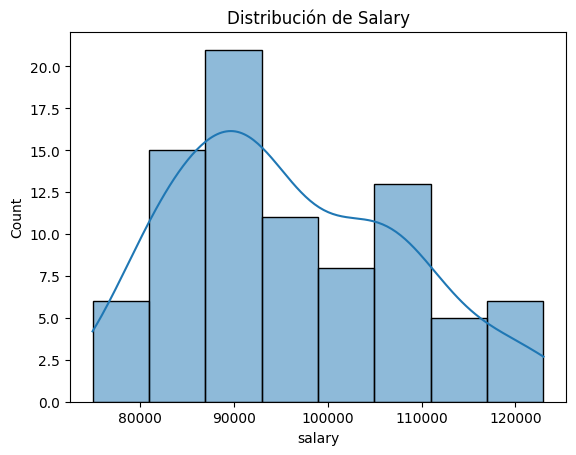


Interpretación:
Observa si la distribución es normal o sesgada.


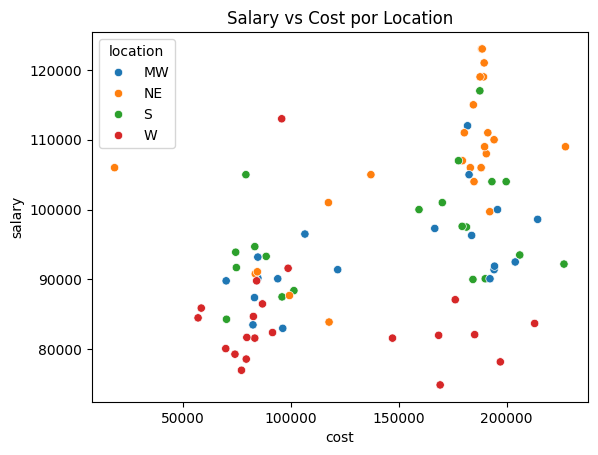


Interpretación:
Se observa relación positiva entre costo y salario en algunas localidades.


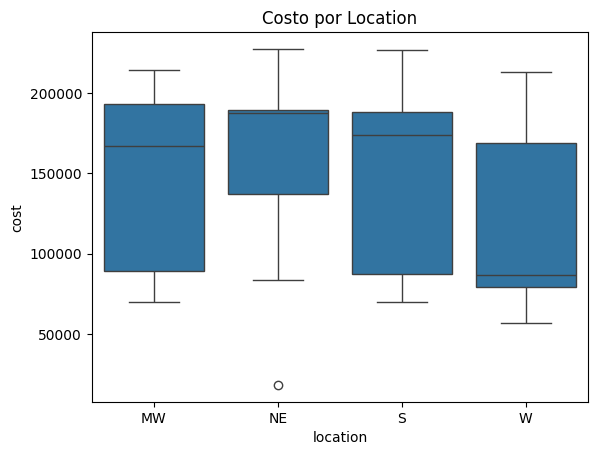


Interpretación:
Permite ver diferencias de costo entre localidades.


In [15]:
# Analisis exploratorio
# Histograma salary
plt.figure()
sns.histplot(df['salary'], kde=True)
plt.title("Distribución de Salary")
plt.show()

print("\nInterpretación:")
print("Observa si la distribución es normal o sesgada.")


# Scatter salary vs cost con color por location
plt.figure()
sns.scatterplot(data=df, x='cost', y='salary', hue='location')
plt.title("Salary vs Cost por Location")
plt.show()

print("\nInterpretación:")
print("Se observa relación positiva entre costo y salario en algunas localidades.")


# Boxplot cost por location
plt.figure()
sns.boxplot(data=df, x='location', y='cost')
plt.title("Costo por Location")
plt.show()

print("\nInterpretación:")
print("Permite ver diferencias de costo entre localidades.")


# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [16]:
# Construccion del modelo
# Variables independientes (ya con dummies)
X = df_dummies.drop('salary', axis=1)
y = df_dummies['salary']

modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes
print("\nIntercepto:", modelo.intercept_)
print("Coeficientes:")
for col, coef in zip(X.columns, modelo.coef_):
    print(f"{col}: {coef}")

print("\nInterpretación:")
print("""
- cost: cuánto aumenta el salario por cada unidad adicional de costo.
- location_X: cambio en salario respecto a la categoría base (la que se eliminó).
""")


Intercepto: 84988.71622754404
Coeficientes:
cost: 0.06051753417141942
location_NE: 12032.819692403562
location_S: 2800.345026332499
location_W: -7721.420103045976

Interpretación:

- cost: cuánto aumenta el salario por cada unidad adicional de costo.
- location_X: cambio en salario respecto a la categoría base (la que se eliminó).



# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

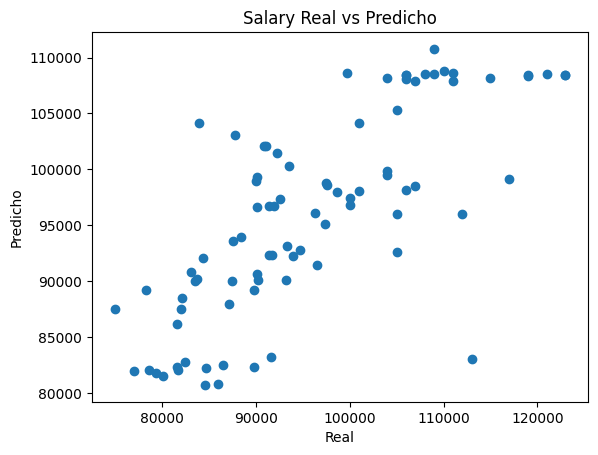

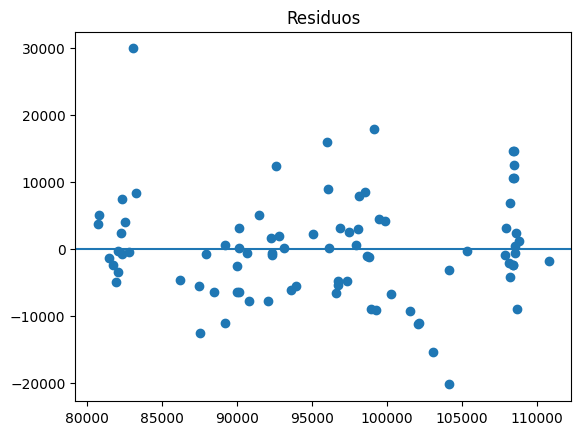


Interpretación:
Los residuos deberían distribuirse aleatoriamente alrededor de 0.


In [17]:
# Analisis de residuos
y_pred = modelo.predict(X)
residuos = y - y_pred

# Real vs Predicho
plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Salary Real vs Predicho")
plt.show()

# Residuos
plt.figure()
plt.scatter(y_pred, residuos)
plt.axhline(0)
plt.title("Residuos")
plt.show()

print("\nInterpretación:")
print("Los residuos deberían distribuirse aleatoriamente alrededor de 0.")


# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [18]:
# evaluacion del modelo
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nMétricas:")
print("MSE:", mse)
print("R2:", r2)

print("\nInterpretación:")
print("""
- MSE bajo indica buen ajuste.
- R2 cercano a 1 indica que el modelo explica bien la variabilidad del salario.
""")


Métricas:
MSE: 60480269.14657189
R2: 0.5705089716684086

Interpretación:

- MSE bajo indica buen ajuste.
- R2 cercano a 1 indica que el modelo explica bien la variabilidad del salario.



# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [20]:
# ANOVA con stastmodel

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/.ipynb_checkpoints/college.csv')

# Seleccionar variables
df = df[['salary', 'cost', 'location']]

# Convertir a categórica
df['location'] = df['location'].astype('category')


# MODELO OLS (REGRESIÓN)
modelo = smf.ols('salary ~ cost + C(location)', data=df).fit()

# Resumen del modelo
print(modelo.summary())

# ANOVA
anova_table = sm.stats.anova_lm(modelo, typ=2)  # typ=2 es el más usado

print("\nTabla ANOVA:")
print(anova_table)

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     26.57
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.96e-14
Time:                        23:18:04   Log-Likelihood:                -882.12
No. Observations:                  85   AIC:                             1774.
Df Residuals:                      80   BIC:                             1786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          8.499e+04   3092.65